In [16]:
import os
import numpy as np
from tqdm import tqdm
import scipy.io as sio

import scanpy as sc
from scanpy import read_visium, read_10x_mtx
import argparse
import pickle
import pandas as pd
import warnings
import json
from pathlib import Path
from typing import Union, Optional
from anndata import AnnData
from matplotlib.image import imread
import scprep as scp

# only need to run once to save hvg_matrix.npy
# filter expression matrices to only include HVGs shared across all datasets


def hvg_selection_and_pooling(exp_paths, samp_names, n_top_genes=1000):
    # input n expression matrices paths, output n expression matrices with only the union of the HVGs

    # read adata and find hvgs
    hvg_bools = []
    for d in exp_paths:
        adata = sio.mmread(d)
        adata = adata.toarray()
        print(adata.shape)
        adata = sc.AnnData(X=adata.T, dtype=adata.dtype)

        # Preprocess the data
        sc.pp.normalize_total(adata)
        sc.pp.log1p(adata)
        sc.pp.highly_variable_genes(adata, n_top_genes=n_top_genes)

        # save hvgs
        hvg = adata.var['highly_variable']

        hvg_bools.append(hvg)

    # find union of hvgs
    hvg_union = hvg_bools[0]
    for i in range(1, len(hvg_bools)):
        print(sum(hvg_union), sum(hvg_bools[i]))
        hvg_union = hvg_union | hvg_bools[i]

    print("Number of HVGs: ", hvg_union.sum())

    # filter expression matrices
    filtered_exp_mtxs = []
    for d in exp_paths:
        adata = sio.mmread(d)
        adata = adata.toarray()
        adata = adata[hvg_union]
        filtered_exp_mtxs.append(adata)

    return filtered_exp_mtxs


def read_visium_alex(path: Union[str, Path],
                     *,
                     count_dir: str = 'raw_feature_bc_matrix',
                     library_id: str = None,
                     load_images: Optional[bool] = True,
                     source_image_path: Optional[Union[str, Path]] = None
                     ) -> AnnData:
    path = Path(path)
    adata = read_10x_mtx(path / count_dir)
    print(adata)
    adata.uns['spatial'] = dict()

    adata.uns["spatial"][library_id] = dict()
    if load_images:
        files = dict(
            tissue_positions_file=path / 'spatial/tissue_positions_list.csv',
            scalefactors_json_file=path / 'spatial/scalefactors_json.json',
            hires_image=path / 'spatial/tissue_hires_image.png',
            lowres_image=path / 'spatial/tissue_lowres_image.png',
        )
        for f in files.values():
            if not f.exists():
                if any(x in str(f) for x in ["hires_image", "lowres_image"]):
                    warnings.warn(
                        f"You seem to be missing an image file.\n"
                        f"Could not find '{f}'."
                    )
                else:
                    raise OSError(f"Could not find '{f}'")
        adata.uns['spatial'][library_id]['images'] = dict()
        for res in ['hires', 'lowres']:
            try:
                adata.uns['spatial'][library_id]['images'][res] = imread(
                    str(files[f'{res}_image'])
                )
            except Exception:
                raise OSError(f"Could not find '{res}_image'")

        # read json scalefactors
        adata.uns["spatial"][library_id]['scalefactors'] = json.loads(
            files['scalefactors_json_file'].read_bytes()
        )

        adata.uns["spatial"][library_id]["metadata"] = {}

        # read coordinates
        positions = pd.read_csv(files['tissue_positions_file'], header=None)
        positions.columns = [
            'barcode',
            'in_tissue',
            'array_row',
            'array_col',
            'pxl_col_in_fullres',
            'pxl_row_in_fullres',
        ]
        positions.index = positions['barcode']

        adata.obs = adata.obs.join(positions, how="left")

        adata.obsm['spatial'] = adata.obs[
            ['pxl_row_in_fullres', 'pxl_col_in_fullres']
        ].to_numpy()
        adata.obs.drop(
            columns=['barcode', 'pxl_row_in_fullres', 'pxl_col_in_fullres'],
            inplace=True,
        )

        # put image path in uns
        if source_image_path is not None:
            # get an absolute path
            source_image_path = str(Path(source_image_path).resolve())
            adata.uns["spatial"][library_id]["metadata"]["source_image_path"] = str(
                source_image_path
            )

    return adata


def intersect_section_genes(adata_list):
    shared = set.intersection(*[set(adata.var_names) for adata in adata_list])
    return list(shared)


def adata_hvg_selection_and_pooling(adata_list, n_top_genes=1000):
    shared = intersect_section_genes(adata_list)
    #
    hvg_bools = []

    for adata in adata_list:
        adata.var_names_make_unique()
        # Subset to the spots in barcodes.tsv
        if adata.uns['library_id'] in samps1:
            index = \
                pd.read_csv(f"D:\dataset\Alex_NatGen/{adata.uns['library_id']}/filtered_count_matrix/barcodes.tsv.gz",
                            sep="\t",
                            header=None)[0].tolist()
        elif adata.uns['library_id'] in samps2:
            index = \
                pd.read_csv(
                    rf"D:\dataset\10xGenomics/{adata.uns['library_id']}/filtered_count_matrix/barcodes.tsv.gz",
                    sep="\t", header=None)[0].tolist()
        adata = adata[index].copy()
        # Subset to shared genes
        adata = adata[:, shared]
        print(adata.shape)
        # Preprocess the data
        sc.pp.normalize_total(adata)
        sc.pp.log1p(adata)
        sc.pp.highly_variable_genes(adata, n_top_genes=n_top_genes)

        # save hvgs
        hvg = adata.var['highly_variable']
        hvg_bools.append(hvg)

    hvg_union = hvg_bools[0]
    hvg_intersection = hvg_bools[0]
    for i in range(1, len(hvg_bools)):
        print(sum(hvg_union), sum(hvg_bools[i]))
        hvg_union = hvg_union | hvg_bools[i]
        print(sum(hvg_intersection), sum(hvg_bools[i]))
        hvg_intersection = hvg_intersection & hvg_bools[i]

    print("Number of HVGs: ", hvg_union.sum())
    print("Number of HVGs (intersection): ", hvg_intersection.sum())

    with open('hvgs_intersection6.pickle', 'wb') as handle:
        pickle.dump(hvg_intersection, handle, protocol=pickle.HIGHEST_PROTOCOL)
    with open('hvgs_union.pickle6', 'wb') as handle:
        pickle.dump(hvg_union, handle, protocol=pickle.HIGHEST_PROTOCOL)

    # Add all the markers
    with open(r'D:\mclSTExp\mclSTExp-main\mclSTExp-main\data\1000hvg_common.pkl', 'rb') as f:
        gene_list = pickle.load(f).to_list()

    # hvg_union[gene_list] = True

    filtered_exp_mtxs = []
    for adata in adata_list:
        adata.var_names_make_unique()
        # Subset to the spots in barcodes.tsv
        if adata.uns['library_id'] in samps1:
            index = \
            pd.read_csv(f"D:\dataset\Alex_NatGen/{adata.uns['library_id']}/filtered_count_matrix/barcodes.tsv.gz",
                        sep="\t", header=None)[0].tolist()
        elif adata.uns['library_id'] in samps2:
            index = \
            pd.read_csv(rf"D:\dataset\10xGenomics/{adata.uns['library_id']}/filtered_count_matrix/barcodes.tsv.gz",
                        sep="\t", header=None)[0].tolist()
        adata = adata[index].copy()
        # Subset to shared genes
        # adata = adata[:, shared]
        filtered_exp_mtxs.append(adata[:, gene_list].X.T.toarray())
    return filtered_exp_mtxs


samps1 = ["1142243F", "CID4290", "CID4465", "CID44971", "CID4535", "1160920F"]
samps2 = ["block1", "block2", "FFPE"]

samps = samps1 + samps2
paths1 = [f"D:\dataset\Alex_NatGen/{samp}"
          for samp in samps1]
adata_list1 = [read_visium_alex(path) for path in paths1]
adata_list2 = [read_visium(rf"D:\dataset\10xGenomics/{samp}") for samp in samps2]
adata_list = adata_list1 + adata_list2
for i, adata in enumerate(adata_list):
    adata.uns['library_id'] = samps[i]

filtered_mtx = adata_hvg_selection_and_pooling(adata_list)


preprocessed_mtx = []
for i, mtx in enumerate(filtered_mtx):

    log_transformed_expression = scp.transform.log(scp.normalize.library_size_normalize(mtx))
    preprocessed_mtx.append(log_transformed_expression)
    pathset = f"./data/preprocessed_expression_matrices/Alex_10x_hvg/{samps[i]}"
    if not os.path.exists(pathset):
        os.makedirs(pathset)
    np.save(f"./data/preprocessed_expression_matrices/Alex_10x_hvg/{samps[i]}/preprocessed_matrix.npy",
            log_transformed_expression)
    print(f"her_data_preprocessed_mtx[{i}]:", log_transformed_expression.shape)


AnnData object with n_obs × n_vars = 4992 × 36601
    var: 'gene_ids', 'feature_types'
AnnData object with n_obs × n_vars = 4992 × 36601
    var: 'gene_ids', 'feature_types'
AnnData object with n_obs × n_vars = 4992 × 36601
    var: 'gene_ids', 'feature_types'
AnnData object with n_obs × n_vars = 4992 × 36601
    var: 'gene_ids', 'feature_types'
AnnData object with n_obs × n_vars = 4992 × 36601
    var: 'gene_ids', 'feature_types'
AnnData object with n_obs × n_vars = 4992 × 36601
    var: 'gene_ids', 'feature_types'
(4784, 17941)


C:\Users\DELL\anaconda3\envs\STA\lib\site-packages\scanpy\preprocessing\_normalization.py:207: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


(2432, 17941)


C:\Users\DELL\anaconda3\envs\STA\lib\site-packages\scanpy\preprocessing\_normalization.py:207: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


(1211, 17941)


...

(3987, 17941)


C:\Users\DELL\anaconda3\envs\STA\lib\site-packages\scanpy\preprocessing\_normalization.py:207: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


(2518, 17941)


C:\Users\DELL\anaconda3\envs\STA\lib\site-packages\scanpy\preprocessing\_normalization.py:207: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


1000 1000
1000 1000
1905 1000
95 1000
2633 1000
27 1000
3269 1000
18 1000
3892 1000
14 1000
4410 1000
11 1000
4775 1000
11 1000
5138 1000
10 1000
Number of HVGs:  5682
Number of HVGs (intersection):  8
her_data_preprocessed_mtx[0]: (685, 4784)
her_data_preprocessed_mtx[1]: (685, 2432)
her_data_preprocessed_mtx[2]: (685, 1211)
her_data_preprocessed_mtx[3]: (685, 1162)
her_data_preprocessed_mtx[4]: (685, 1127)
her_data_preprocessed_mtx[5]: (685, 4895)
her_data_preprocessed_mtx[6]: (685, 3798)
her_data_preprocessed_mtx[7]: (685, 3987)
her_data_preprocessed_mtx[8]: (685, 2518)


In [4]:
import anndata
import torch
import torch.nn.functional as F
from dataset import TenxDataset
from tqdm import tqdm
from model import mclSTExp_Attention
from torch.utils.data import DataLoader
import os
import numpy as np
import pickle
from train import generate_args
from utils import get_R
from sklearn.metrics import mean_squared_error, mean_absolute_error

def build_loaders_inference():
    examples1 = ["1142243F", "CID4290", "CID4465", "CID44971", "CID4535", "1160920F"]
    examples2 = ["block1", "block2", "FFPE"]

    datasets = [
                   TenxDataset(image_path=f"D:\dataset\Alex_NatGen/{example}/image.tif",
                               spatial_pos_path=f"D:\dataset\Alex_NatGen/{example}/spatial/tissue_positions_list.csv",
                               reduced_mtx_path=f"./data/preprocessed_expression_matrices/Alex_10x_hvg/{example}/preprocessed_matrix.npy",
                               barcode_path=f"D:\dataset\Alex_NatGen/{example}/filtered_count_matrix/barcodes.tsv.gz")
                   for example in examples1
               ] + [
                   TenxDataset(image_path=rf"D:\dataset\10xGenomics/{example}/image.tif",
                               spatial_pos_path=rf"D:\dataset\10xGenomics/{example}/spatial/tissue_positions_list.csv",
                               reduced_mtx_path=f"./data/preprocessed_expression_matrices/Alex_10x_hvg/{example}/preprocessed_matrix.npy",
                               barcode_path=rf"D:\dataset\10xGenomics/{example}/filtered_count_matrix/barcodes.tsv.gz")
                   for example in examples2
               ]

    dataset = torch.utils.data.ConcatDataset(datasets)
    test_loader = DataLoader(dataset, batch_size=32, shuffle=False)

    print("Finished building loaders")
    return test_loader


def get_embeddings(model_path, model):
    test_loader = build_loaders_inference()

    state_dict = torch.load(model_path)
    new_state_dict = {}
    for key in state_dict.keys():
        new_key = key.replace('module.', '')  # remove the prefix 'module.'
        new_key = new_key.replace('well', 'spot')  # for compatibility with prior naming
        new_state_dict[new_key] = state_dict[key]

    model.load_state_dict(new_state_dict)
    # Move model to GPU
    model = model.cuda()
    model.eval()

    print("Finished loading model")

    test_image_embeddings = []
    spot_embeddings = []
    with torch.no_grad():
        for batch in tqdm(test_loader):
            image_features = model.image_encoder(batch["image"].cuda())
            image_embeddings = model.image_projection(image_features)
            test_image_embeddings.append(image_embeddings)

            spot_feature = batch["expression"].cuda()
            x = batch["position"][:, 0].long().cuda()
            y = batch["position"][:, 1].long().cuda()
            centers_x = model.x_embed(x)
            centers_y = model.y_embed(y)
            spot_feature = spot_feature + centers_x + centers_y
            # spot_embeddings.append(model.spot_projection(spot_feature + centers_x + centers_y))

            # x = batch["position"][:, 0].long().cuda()
            # y = batch["position"][:, 1].long().cuda()
            # centers_x = model.x_embed(x)
            # centers_y = model.y_embed(y)

            # coordinates = batch["position"].float().cuda()
            # scale = max(coordinates[:, 0].max() - coordinates[:, 0].min(),
            #             coordinates[:, 1].max() - coordinates[:, 1].min())
            # coordinates[:, 0] = (coordinates[:, 0] - coordinates[:, 0].min()) / scale
            # coordinates[:, 1] = (coordinates[:, 1] - coordinates[:, 1].min()) / scale
            # pe = model.pe_enc(coordinates)
            # pe = model.act(pe)
            # pe = model.layer_norm(pe)
            # spot_feature = spot_feature + pe
            spot_features = spot_feature.unsqueeze(dim=0)
            spot_embedding = model.spot_encoder(spot_features)
            spot_embedding = model.spot_projection(spot_embedding).squeeze(dim=0)
            spot_embeddings.append(spot_embedding)
    return torch.cat(test_image_embeddings), torch.cat(spot_embeddings)




def find_matches(spot_embeddings, query_embeddings, top_k=1):
    # find the closest matches
    spot_embeddings = torch.tensor(spot_embeddings)
    query_embeddings = torch.tensor(query_embeddings)
    query_embeddings = F.normalize(query_embeddings, p=2, dim=-1)
    spot_embeddings = F.normalize(spot_embeddings, p=2, dim=-1)
    dot_similarity = query_embeddings @ spot_embeddings.T
    print(dot_similarity.shape)
    _, indices = torch.topk(dot_similarity.squeeze(0), k=top_k)

    return indices.cpu().numpy()


def save_embeddings(model_path, save_path, datasize):
    # args = generate_args()
    args = type('Args', (), {
        'encoder_name': 'densenet121',
        'dim': 685,
        'temperature': 1.0,
        'image_embedding_dim': 1024,
        'projection_dim': 256,
        'heads_num': 8,
        'heads_dim': 64,
        'heads_layers': 2,
        'dropout': 0.0
    })()
    model = mclSTExp_Attention(encoder_name=args.encoder_name,
                               spot_dim=args.dim,
                               temperature=args.temperature,
                               image_dim=args.image_embedding_dim,
                               projection_dim=args.projection_dim,
                               heads_num=args.heads_num,
                               heads_dim=args.heads_dim,
                               head_layers=args.heads_layers,
                               dropout=args.dropout)

    img_embeddings_all, spot_embeddings_all = get_embeddings(model_path, model)

    img_embeddings_all = img_embeddings_all.cpu().numpy()
    spot_embeddings_all = spot_embeddings_all.cpu().numpy()
    print(img_embeddings_all.shape)
    print(spot_embeddings_all.shape)

    if not os.path.exists(save_path):
        os.makedirs(save_path)

    for i in range(len(datasize)):
        index_start = sum(datasize[:i])
        index_end = sum(datasize[:i + 1])
        image_embeddings = img_embeddings_all[index_start:index_end]
        spot_embeddings = spot_embeddings_all[index_start:index_end]
        print(image_embeddings.shape)
        print(spot_embeddings.shape)
        np.save(save_path + "img_embeddings_" + str(i + 1) + ".npy", image_embeddings.T)
        np.save(save_path + "spot_embeddings_" + str(i + 1) + ".npy", spot_embeddings.T)


SAVE_EMBEDDINGS = True
samps1 = ["1142243F", "CID4290", "CID4465", "CID44971", "CID4535", "1160920F"]
samps2 = ["block1", "block2", "FFPE"]
samps = samps1 + samps2

datasize = [4784, 2432, 1211, 1162, 1127, 4895, 3798, 3987, 2518]

if SAVE_EMBEDDINGS:
    for fold in range(9):
        save_embeddings(model_path=f"./model_result/10x/{samps[fold]}/best_{fold}.pt",
                        save_path=f"./embedding_result/10x_result/embeddings_{fold}/",
                        datasize=datasize)


spot_expressions = [np.load(f"./data/preprocessed_expression_matrices/Alex_10x_hvg/{samp}/preprocessed_matrix.npy")
                    for samp in samps]
correlation_across_cell = []
mse_list = []
mae_list = []
heg_pcc_list = []
hvg_pcc_list = []
for fold in range(9):

    save_path = f"./embedding_result/10x_result/embeddings_{fold}/"
    spot_embeddings = [np.load(save_path + f"spot_embeddings_{i + 1}.npy") for i in range(9)]
    image_embeddings = np.load(save_path + f"img_embeddings_{fold + 1}.npy")

    # query
    image_query = image_embeddings
    expression_gt = spot_expressions[fold]
    spot_embeddings = spot_embeddings[:fold] + spot_embeddings[fold + 1:]
    spot_expressions_rest = spot_expressions[:fold] + spot_expressions[fold + 1:]

    spot_key = np.concatenate(spot_embeddings, axis=1)
    expression_key = np.concatenate(spot_expressions_rest, axis=1)

    save_path = f"./10x_pred/preds_{fold}/"
    os.makedirs(save_path, exist_ok=True)
    if image_query.shape[1] != 256:
        image_query = image_query.T
        print("image query shape: ", image_query.shape)
    if expression_gt.shape[0] != image_query.shape[0]:
        expression_gt = expression_gt.T
        print("expression_gt shape: ", expression_gt.shape)
    if spot_key.shape[1] != 256:
        spot_key = spot_key.T
        print("spot_key shape: ", spot_key.shape)
    if expression_key.shape[0] != spot_key.shape[0]:
        expression_key = expression_key.T
        print("expression_key shape: ", expression_key.shape)



    indices = find_matches(spot_key, image_query, top_k=200)
    matched_spot_embeddings_pred = np.zeros((indices.shape[0], spot_key.shape[1]))
    matched_spot_expression_pred = np.zeros((indices.shape[0], expression_key.shape[1]))
    for i in range(indices.shape[0]):
        a = np.linalg.norm(spot_key[indices[i, :], :] - image_query[i, :], axis=1)
        # from sklearn.metrics.pairwise import cosine_similarity
        # a = 1 - cosine_similarity(spot_key[indices[i, :], :], image_query[i, :].reshape(1, -1))
        reciprocal_of_square_a = np.reciprocal(a ** 2)
        weights = reciprocal_of_square_a / np.sum(reciprocal_of_square_a)
        weights = weights.flatten()
        matched_spot_embeddings_pred[i, :] = np.average(spot_key[indices[i, :], :], axis=0, weights=weights)
        matched_spot_expression_pred[i, :] = np.average(expression_key[indices[i, :], :], axis=0,
                                                        weights=weights)
    print("matched spot embeddings pred shape: ", matched_spot_embeddings_pred.shape)
    print("matched spot expression pred shape: ", matched_spot_expression_pred.shape)
        # np.save(save_path + "matched_spot_expression_pred.npy", matched_spot_expression_pred.T)

    true = expression_gt
    pred = matched_spot_expression_pred


    mse = mean_squared_error(true, pred)
    mse_list.append(mse)
    print("Mean Squared Error (MSE): ", mse)
    mae = mean_absolute_error(true, pred)
    mae_list.append(mae)
    print("Mean Absolute Error (MAE): ", mae)

    with open(r'./data/1000hvg_common.pkl', 'rb') as f:
        gene_list = pickle.load(f).to_list()
    adata_ture = anndata.AnnData(true)
    adata_pred = anndata.AnnData(pred)

    adata_pred.var_names = gene_list
    adata_ture.var_names = gene_list

    gene_mean_expression = np.mean(adata_ture.X, axis=0)
    top_50_genes_indices = np.argsort(gene_mean_expression)[::-1][:50]
    top_50_genes_names = adata_ture.var_names[top_50_genes_indices]
    top_50_genes_expression = adata_ture[:, top_50_genes_names]
    top_50_genes_pred = adata_pred[:, top_50_genes_names]

    heg_pcc, heg_p = get_R(top_50_genes_pred, top_50_genes_expression)
    hvg_pcc, hvg_p = get_R(adata_pred, adata_ture)
    hvg_pcc = hvg_pcc[~np.isnan(hvg_pcc)]

    heg_pcc_list.append(np.mean(heg_pcc))
    hvg_pcc_list.append(np.mean(hvg_pcc))
print(f"avg heg pcc: {np.mean(heg_pcc_list):.4f}")
print(f"avg hvg pcc: {np.mean(hvg_pcc_list):.4f}")
print(f"Mean Squared Error (MSE): {np.mean(mse_list):.4f}")
print(f"Mean Absolute Error (MAE): {np.mean(mae_list):.4f}")







Finished loading all files
Finished loading all files
Finished loading all files
Finished loading all files
Finished loading all files
Finished loading all files
Finished loading all files
Finished loading all files
Finished loading all files
Finished building loaders


C:\Users\DELL\AppData\Local\Temp\ipykernel_45468\2434067963.py:43: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(model_path)


Finished loading model


100%|██████████| 810/810 [01:01<00:00, 13.19it/s]


(25914, 256)
(25914, 256)
(4784, 256)
(4784, 256)
(2432, 256)
(2432, 256)
(1211, 256)
(1211, 256)
(1162, 256)
(1162, 256)
(1127, 256)
(1127, 256)
(4895, 256)
(4895, 256)
(3798, 256)
(3798, 256)
(3987, 256)
(3987, 256)
(2518, 256)
(2518, 256)
Finished loading all files
Finished loading all files
Finished loading all files
Finished loading all files
Finished loading all files
Finished loading all files
Finished loading all files
Finished loading all files
Finished loading all files
Finished building loaders


...

(25914, 256)
(25914, 256)
(4784, 256)
(4784, 256)
(2432, 256)
(2432, 256)
(1211, 256)
(1211, 256)
(1162, 256)
(1162, 256)
(1127, 256)
(1127, 256)
(4895, 256)
(4895, 256)
(3798, 256)
(3798, 256)
(3987, 256)
(3987, 256)
(2518, 256)
(2518, 256)
image query shape:  (4784, 256)
expression_gt shape:  (4784, 685)
spot_key shape:  (21130, 256)
expression_key shape:  (21130, 685)
torch.Size([4784, 21130])
matched spot embeddings pred shape:  (4784, 256)
matched spot expression pred shape:  (4784, 685)
Mean Squared Error (MSE):  0.16749346472034618
Mean Absolute Error (MAE):  0.3419456197621248


D:\TRI\mclSTExp-main\mclSTExp-main\utils.py:58: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, pv = func(adata1[:, g], adata2[:, g])


image query shape:  (2432, 256)
expression_gt shape:  (2432, 685)
spot_key shape:  (23482, 256)
expression_key shape:  (23482, 685)
torch.Size([2432, 23482])
matched spot embeddings pred shape:  (2432, 256)
matched spot expression pred shape:  (2432, 685)
Mean Squared Error (MSE):  0.2596182811106124
Mean Absolute Error (MAE):  0.4270156215389061
image query shape:  (1211, 256)
expression_gt shape:  (1211, 685)
spot_key shape:  (24703, 256)
expression_key shape:  (24703, 685)
torch.Size([1211, 24703])
matched spot embeddings pred shape:  (1211, 256)
matched spot expression pred shape:  (1211, 685)
Mean Squared Error (MSE):  0.3488608988897425
Mean Absolute Error (MAE):  0.4988479617448735
image query shape:  (1162, 256)
expression_gt shape:  (1162, 685)
spot_key shape:  (24752, 256)
expression_key shape:  (24752, 685)
torch.Size([1162, 24752])
matched spot embeddings pred shape:  (1162, 256)
matched spot expression pred shape:  (1162, 685)
Mean Squared Error (MSE):  0.36161446570910477

D:\TRI\mclSTExp-main\mclSTExp-main\utils.py:58: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, pv = func(adata1[:, g], adata2[:, g])
C:\Users\DELL\anaconda3\envs\STA\lib\site-packages\scipy\stats\_stats_py.py:4905: RuntimeWarning: divide by zero encountered in divide
  normym = ymax * xp.linalg.vector_norm(ym/ymax, axis=axis, keepdims=True)


avg heg pcc: 0.3071
avg hvg pcc: 0.1555
Mean Squared Error (MSE): 0.2452
Mean Absolute Error (MAE): 0.3999


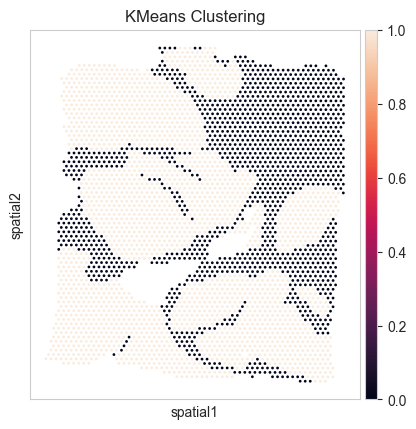

In [19]:

import os
import numpy as np
import scanpy as sc
import pandas as pd


def find_top_genes(adata, label_key='label', cancer_label=0, non_cancer_label=1, top_n=4):

    cancer_cells = adata[adata.obs[label_key] == cancer_label]
    non_cancer_cells = adata[adata.obs[label_key] == non_cancer_label]

    cancer_expression = np.asarray(cancer_cells.X.mean(axis=0)).ravel()
    non_cancer_expression = np.asarray(non_cancer_cells.X.mean(axis=0)).ravel()

    cancer_expression_df = pd.DataFrame(
        {'Cancer Area Expression': cancer_expression},
        index=adata.var_names
    )
    non_cancer_expression_df = pd.DataFrame(
        {'Non-cancer Area Expression': non_cancer_expression},
        index=adata.var_names
    )

    expression_df = pd.concat([cancer_expression_df, non_cancer_expression_df], axis=1)

    expression_df['Expression Difference'] = (
        expression_df['Cancer Area Expression'] - expression_df['Non-cancer Area Expression']
    )

    top_cancer_genes = expression_df.sort_values('Expression Difference', ascending=False).head(top_n)

    top_non_cancer_genes = expression_df.sort_values('Expression Difference', ascending=True).head(top_n)

    return top_cancer_genes, top_non_cancer_genes


with open('D:\\dataset\\10xGenomics\\label.txt', 'r') as f:
    labels = f.read().strip().split()

labels = np.array(labels, dtype=int)

root = 'D:/dataset/10xGenomics/block1/'
file = 'pred_our.h5ad'
path = os.path.join(root, file)

adata = sc.read(path)

adata.var_names_make_unique()

adata.obs['label'] = labels

save_path = os.path.join(root, 'sampledata_with_label.h5ad')
adata.write(save_path)

palette = ['#ff7f0e', '#1f77b4']
sc.pl.spatial(adata, color='label', title='KMeans Clustering', spot_size=150, palette=palette, show=True)




In [18]:
import scanpy as sc
adata = sc.read("D:/T1/151673/recovered_data.h5ad")

In [6]:
adata

AnnData object with n_obs × n_vars = 3639 × 1000
    obs: 'in_tissue', 'array_row', 'array_col', 'layer'
    obsm: 'coord'

In [7]:
adata.obsm['spatial'] = adata.obsm['coord']
spatial = adata.obsm['spatial'].copy()
spatial[:, 1] = spatial[:, 1].max() - spatial[:, 1]
adata.obsm['spatial'] = spatial

In [8]:
from GraphST import GraphST
import SpatialGlue
import torch
import os

os.environ['R_HOME'] = r'D:\R-4.5.0'
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
# define model
model = GraphST.GraphST(adata, device=device, epochs=1)

# train model
adata = model.train()
print(adata)


C:\Users\DELL\anaconda3\envs\STA\lib\site-packages\scanpy\preprocessing\_highly_variable_genes.py:75: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  warnings.warn(


Begin to train ST data...


100%|██████████| 1/1 [00:00<00:00,  2.00it/s]

Optimization finished for ST data!
AnnData object with n_obs × n_vars = 3639 × 1000
    obs: 'in_tissue', 'array_row', 'array_col', 'layer'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'mean', 'std'
    uns: 'hvg', 'log1p'
    obsm: 'coord', 'spatial', 'distance_matrix', 'graph_neigh', 'adj', 'label_CSL', 'feat', 'feat_a', 'emb'


In [9]:
from SpatialGlue.utils import clustering

n_clusters = 7
tool = 'mclust'  # mclust, leiden, and louvain
radius = 30
clustering(adata, key='emb', n_clusters=n_clusters, radius=radius, method=tool, refinement=True)



Error importing in API mode: ImportError('On Windows, cffi mode "ANY" is only "ABI".')
Trying to import in ABI mode.
R callback write-console:                    __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.1.1
Type 'citation("mclust")' for citing this R package in publications.
  
R callback write-console: In addition:   
R callback write-console: Warning message:
  
R callback write-console: package 'mclust' was built under R version 4.5.1 
  


fitting ...
  |======================================================================| 100%


In [10]:
print(adata.obs['layer'].shape)
adata

(3639,)


AnnData object with n_obs × n_vars = 3639 × 1000
    obs: 'in_tissue', 'array_row', 'array_col', 'layer', 'mclust', 'domain'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'mean', 'std'
    uns: 'hvg', 'log1p'
    obsm: 'coord', 'spatial', 'distance_matrix', 'graph_neigh', 'adj', 'label_CSL', 'feat', 'feat_a', 'emb', 'emb_pca'

In [11]:
print(adata.obs['mclust'].shape)

(3639,)


In [12]:
layer_nan = adata.obs['layer'].isna().sum()
mclust_nan = adata.obs['mclust'].isna().sum()

In [13]:
valid_indices = ~(adata.obs['layer'].isna() | adata.obs['mclust'].isna())
layer_clean = adata.obs['layer'][valid_indices]
mclust_clean = adata.obs['mclust'][valid_indices]

In [14]:
from sklearn.metrics import adjusted_rand_score as ari

ARI = ari(layer_clean, mclust_clean)
print(f"ARI: {ARI:.4f}")

ARI: 0.365672592196804924213893173146061599254608154296875


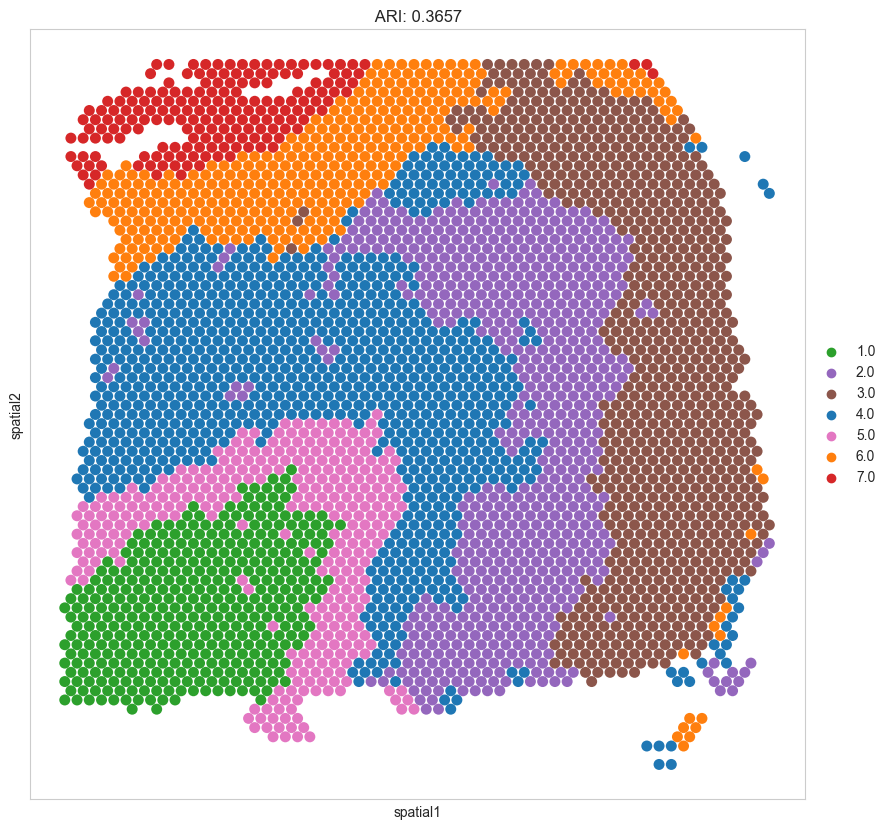

In [15]:
from matplotlib import pyplot as plt


palette = [
    "#2CA02C" ,
    "#9467BD" ,
    "#8C564B",
    "#1F77B4" ,
    "#E377C2",
    "#FF7F0E",
    "#D62728"
]

fig, ax = plt.subplots(figsize=(10, 10))
sc.pl.embedding(
    adata,
    basis='spatial',
    color='mclust', #domain
    title=f" ARI: {ARI:.4f}",  # 修正标题格式
    s=250,
    show=False,
    ax=ax,
    palette=palette
)
plt.savefig("C:/Users/DELL/Desktop/work1/cluster/graphST.pdf", bbox_inches='tight')

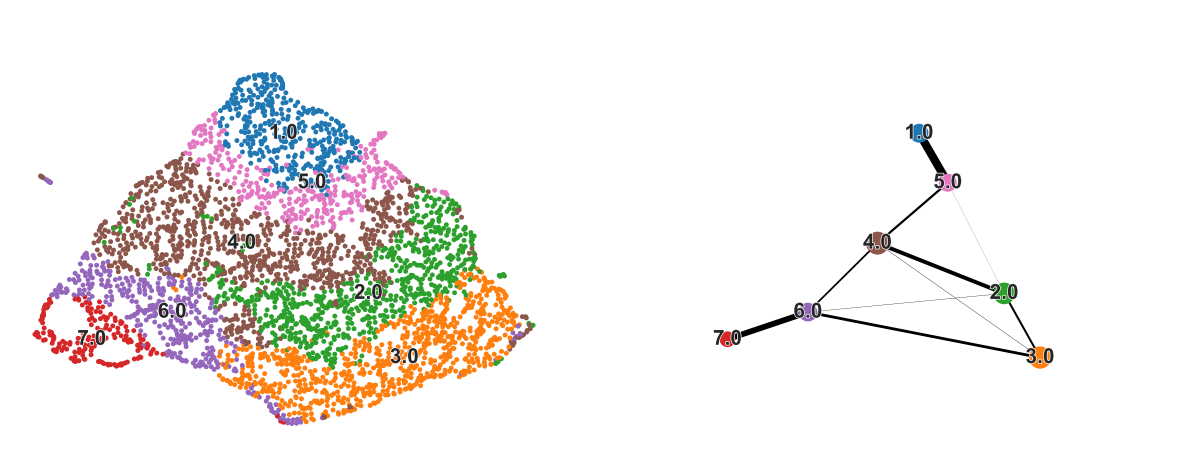

In [16]:
import matplotlib.pyplot as plt
import scanpy as sc

sc.pp.neighbors(adata, n_neighbors=6, n_pcs=1000, use_rep='emb')


sc.tl.umap(adata)


sc.tl.paga(adata, groups='mclust')


palette = [
    "#1F77B4" ,
    "#2CA02C",
    "#FF7F0E",
    "#8C564B",
    "#E377C2",
    "#9467BD",
    "#D62728"
]


sc.pl.paga_compare(adata,
                   legend_fontsize=15,
                   frameon=False,
                   size=50,
                   title=' ',
                   legend_fontoutline=1,
                   show=True,
                   color='mclust',
                   palette=palette,
                   save='umap_plot.pdf')


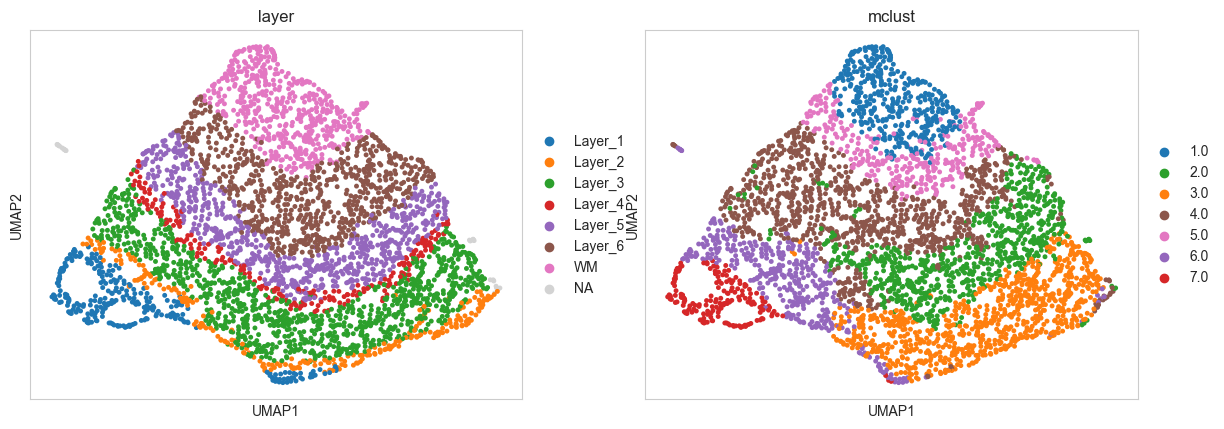

In [17]:
sc.pp.neighbors(adata, n_neighbors=6, n_pcs=1000, use_rep='emb')

sc.tl.umap(adata)

sc.pl.umap(adata, color=['layer', 'mclust'], show=True, size=50, save='umap_plot.pdf')